In [1]:
%pwd

'/home/tzuhsuan/GitHub/QFoam/High-fidelity-Rydberg-control-Z-gates-with-time-optimal-pulses/Manuscript-figures'

In [2]:
import os
import glob
import time
from IPython.display import clear_output

from qutip import *
import math

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

from rdquantum.pulse_shape import Saffman_shape
from rdquantum.fidelity import fidelity
from rdquantum.optimizer.de import de

# plt.rcParams["figure.figsize"] = [8, 5]
plt.rcParams["figure.figsize"] = [4, 8]
plt.rcParams["figure.autolayout"] = True
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.linewidth"] = 2.50
plt.figure(dpi=1200)

root_dir = "Gaussian500_DeltaX"
data_dir_prefix = "Gaussian500_Delta"

<Figure size 4800x9600 with 0 Axes>

# a)

In [3]:
# deltaamp = [1, 2, 3, 6, 8]
# op_fidelity = []
# op_fidelity_r2 = []
# op_tgate = []
# root_dir = "Gaussian500_DeltaX"
# data_dir_prefix = "Gaussian500_Delta"
# for i in range(len(deltaamp)):
#     opinfo_file = "../{}/{}{}/out.npz".format(root_dir, data_dir_prefix, deltaamp[i])
#     opinfo_r2_file = "../{}/{}{}/out_r2.npz".format(root_dir, data_dir_prefix, deltaamp[i])
#     oppulse_file = "../{}/{}{}/out-op_pulse.npz".format(root_dir, data_dir_prefix, deltaamp[i])
#     opinfo = np.load(opinfo_file, allow_pickle=True)
#     opinfo_r2 = np.load(opinfo_r2_file, allow_pickle=True)
#     oppulse = np.load(oppulse_file, allow_pickle=True)
    
#     op_fidelity.append(1-opinfo["op_fidelity"].item(0))
#     op_fidelity_r2.append(1-opinfo_r2["op_fidelity"].item(0))
#     op_tgate.append(oppulse['T_gate'].item(0))

In [4]:
# print(op_fidelity)
# print(op_fidelity_r2)
# print(op_tgate)

# b)

In [5]:
testnpy = np.load("../{}/{}3/out.npz".format(root_dir, data_dir_prefix), allow_pickle=True)
op_pulse = np.load("../{}/{}3/out-op_pulse.npz".format(root_dir, data_dir_prefix), allow_pickle=True)
print(list(testnpy.keys()))
print(list(op_pulse))
print(op_pulse['Omega1'])
print(op_pulse['Omega2'])
print(op_pulse['Delta1'])
# print(op_pulse['Delta2'])
print(op_pulse['T_gate'])
print(testnpy['op_fidelity'])

['populations', 'fidelity', 'pulses', 'op_fidelity']
['Omega1', 'Omega2', 'Delta1', 'T_gate']
[338.90966079]
[499.99999865]
[3000.]
[0.70020951]
0.9990556949943885


In [6]:
Omega1 = op_pulse['Omega1']
Omega2 = op_pulse['Omega2']
Delta1 = op_pulse['Delta1']
# Delta2 = op_pulse['Delta2']
T_gate = op_pulse['T_gate']

Pulses = {'Omega1': Omega1, 'Omega2': Omega2, 
          'Delta1': Delta1, 
          'T_gate': T_gate}

# Pulse shape
T_gate = Pulses['T_gate'][0]         # (mu s) Total gate time
n = 12   # Number of segments
dt = T_gate/n       # (mu s) Duration of each segment

def gaussian(t):
    # return Saffman_shape(t, Pulses['Omega1'], T_gate, n_seg)
    t = t % T_gate
    t0 = T_gate/2
    tau = 0.165*T_gate
    a = np.exp(- t0**2 / tau**2)
    return Pulses['Omega1'][0] * (np.exp(-(t-t0)**2 / tau**2) - a) / (1-a)

# Load data

In [7]:
# c)
out_init01_file = "../{}/{}3/out_init01.npz".format(root_dir, data_dir_prefix)
out_init01 = np.load(out_init01_file, allow_pickle=True)
print("out_init01.keys(): ", list(out_init01.keys()))

# d)
out_init11_file = "../{}/{}3/out_init11.npz".format(root_dir, data_dir_prefix)
out_init11 = np.load(out_init11_file, allow_pickle=True)
print("out_init11.keys(): ", list(out_init11.keys()))

out_init01.keys():  ['P01', 'P0p', 'P0r', 'P000d']
out_init11.keys():  ['P11', 'Ppp', 'P1rr1', 'Prr', 'P00dd']


# Plot

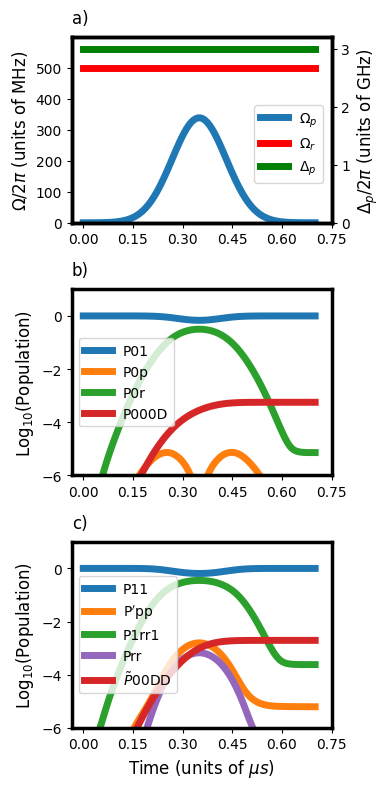

In [8]:
fig, axs = plt.subplots(3,1)

# axa = axs[0,0]
axb = axs[0]
axc = axs[1]
axd = axs[2]
times = np.linspace(0.0, T_gate, 100)

# #axa
# axap = axa.plot(deltaamp, np.log10(op_fidelity), '-o', markersize=8, linewidth=5, label="Infidelity")
# axap2 = axa.plot(deltaamp, np.log10(op_fidelity_r2), '-o', markersize=8, linewidth=5, label="Infidelity-r2")
# axat = axa.twinx()
# axatp = axat.plot(deltaamp, op_tgate, '-o', markersize=8, linewidth=5, label=r"$T_{gate}$", color='r')
# axald = axap + axap2 + axatp
# axalb = [lb.get_label() for lb in axald]
# axa.legend(axald, axalb, bbox_to_anchor=(1.02, .55), fontsize=10)

# axa.set_xlabel(r'$\Delta_{p}$' '(units of GHz)', fontsize=12)
# axa.set_ylabel('Log' r'$_{10}$' r'$(1-F_{Bell})$', fontsize=12)
# axat.set_ylabel(r'$T_{gate}$' ' (units of ' r'$\mu s$' ')', fontsize=12)

# xinterval = np.arange(0, 11, 2)
# y1interval = np.arange(-4, -2, 0.5)
# y2interval = np.arange(0, 2.1, 0.5)
# axa.set_xticks(xinterval)
# axa.set_yticks(y1interval)
# axat.set_yticks(y2interval)

# axa.set_title('a)', loc='left', pad=10)

#axb
pulse_Omega1 = []
pulse_Omega2 = []
pulse_Delta1 = []
for t in times:
    pulse_Omega1.append( gaussian(t))
    pulse_Omega2.append( Omega2[0] )
    pulse_Delta1.append( Delta1[0]/1000 )

axbp = axb.plot(times, pulse_Omega1, linewidth=5, label=r'$\Omega_p$')
axbp2 = axb.plot(times, pulse_Omega2, linewidth=5, label=r'$\Omega_r$', color='r')
# axbp2 = axb.hlines(y=Omega2[0], xmin=0, xmax=T_gate, linewidth=3.5, label=r'$\Omega_2$', color='r')
axbt = axb.twinx()
axbtp = axbt.plot(times, pulse_Delta1, linewidth=5, label=r'$\Delta_p$', color='g')
axbld = axbp + axbp2 + axbtp
axblb = [lb.get_label() for lb in axbld]
axb.legend(axbld, axblb, bbox_to_anchor=(.676, .425), fontsize=10)

# axb.set_xlabel('Time (units of ' r'$\mu s$' ')', fontsize=12) 
axb.set_ylabel(r'$\Omega / 2 \pi$' ' (units of MHz)', fontsize=12)
axbt.set_ylabel(r'$\Delta_p / 2 \pi$' ' (units of GHz)', fontsize=12)
axb.set_ylim(0, 600)
axbt.set_ylim(0, 3.2)

xinterval = np.arange(0, 0.85, 0.15)
y1interval = np.arange(0, 600, 100)
axb.set_xticks(xinterval)
axb.set_yticks(y1interval)

axb.set_title('a)', loc='left', pad=10)

#axc
axc.plot(times, out_init01["P01"], linewidth=5) 
axc.plot(times, out_init01["P0p"], linewidth=5)
axc.plot(times, out_init01["P0r"], linewidth=5)
axc.plot(times, out_init01["P000d"], linewidth=5)

# axc.set_xlabel('Time (units of ' r'$\mu s$' ')', fontsize=12)
axc.set_ylim(-6, 1)
axc.set_ylabel('Log' r'$_{10}$' '(Population)', fontsize=12) 
axc.legend(("P01", "P0p", "P0r", "P000D"), fontsize=10)

xinterval = np.arange(0, 0.8, 0.15)
axc.set_xticks(xinterval)

axc.set_title('b)', loc='left', pad=10)

#axd
axd.plot(times, out_init11["P11"], linewidth=5) 
axd.plot(times, out_init11["Ppp"], linewidth=5)
axd.plot(times, out_init11["P1rr1"], linewidth=5)
axd.plot(times, out_init11["Prr"], linewidth=5, color='tab:purple')
axd.plot(times, out_init11["P00dd"], linewidth=5, color='tab:red')

axd.set_xlabel('Time (units of ' r'$\mu s$' ')', fontsize=12)
axd.set_ylim(-6, 1)
axd.set_ylabel('Log' r'$_{10}$' '(Population)', fontsize=12) 
axd.legend(("P11", "P" r"$'$" "pp", "P1rr1", "Prr", r"$\tilde{P}$""00DD"), fontsize=10)

xinterval = np.arange(0, 0.8, 0.15)
axd.set_xticks(xinterval)

axd.set_title('c)', loc='left', pad=10)

plt.savefig('fig1_500.eps', dpi=1200)